In [ ]:
#!pip install pypdf

In [41]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

True

# 인덱싱

In [3]:
from langchain_community.document_loaders import PyPDFLoader

In [7]:
loader = PyPDFLoader("data/Samsung_Card_Manual_Korean_1.3.pdf")
pages = loader.load()

In [9]:
len(pages)

6

In [10]:
pages[0].page_content[:100]
pages[0].metadata

{'producer': 'Microsoft® Word 2010',
 'creator': 'Microsoft® Word 2010',
 'creationdate': '2019-01-02T09:40:06+09:00',
 'author': 'master',
 'moddate': '2019-01-02T09:40:06+09:00',
 'source': 'data/Samsung_Card_Manual_Korean_1.3.pdf',
 'total_pages': 6,
 'page': 0,
 'page_label': '1'}

In [15]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [15]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
docs= splitter.split_documents(pages)

In [16]:
docs[0].page_content

'사용설명서           SAMSUNG PROPRIETARY \nRevision1.3 \n1 \n \n \n \n \n \n \n \n \n \n \n \n \n \n. \n \n법적 고지 사항 \n삼성 전자는 통지 없이 제품, 정보 및 사양을 변경할 권리를 보유합니다.  \n여기에 언급된 제품 및 사양은 참조용으로만 사용되며, 여기에 언급된 모든 정보는 공지 없이 변경될 수 있고 \n어떠한 종류의 보증도 없이 "있는 그대로" 제공됩니다. 본 문서 및 여기에 명시된 모든 정보는 삼성 전자의 \n유일하고 배타적인 자산으로 보유됩니다. 본 문서에 따라 어떠한 특허권, 저작권, 마스크워크, 상표 또는 기타 \n지적 재산권도 묵시적, 금반언적 또는 기타 어떤 방식으로도 한 당사자가 다른 당사자에게 부여할 수 없습니다. \n삼성 제품은 생명 보조기구, 구명의료기, 의료 기기, 안전 장비 또는 제품의 오류로 인해 사망, 부상 또는 물리적'

In [17]:
docs[1].page_content

'삼성 제품은 생명 보조기구, 구명의료기, 의료 기기, 안전 장비 또는 제품의 오류로 인해 사망, 부상 또는 물리적 \n상해를 야기할 수 있는 유사 제품, 군용 또는 방어 기기 또는 특정 계약/조항이 적용될 수 있는 정부의 조달에 \n사용할 의도로 설계되지 않았습니다. 삼성 제품에 관한 업데이트 또는 추가 정보는 가까운 삼성 대리점에 \n문의하십시오. 모든 브랜드 이름, 상표 및 등록 상표는 해당 소유권자가 소유합니다.  \nCopyright, 2019 Samsung Electronics Co., Ltd. All rights reserved.  \n \nCOPYRIGHT 2019  \n본 자료의 저작권은 삼성 전자에 있습니다. 본 자료의 전부 또는 일부를 무단으로 복제하거나 사용 또는 공개하는 \n행위는 엄격히 금지되며 저작권법에 위배됩니다. \n상표 및 서비스 표시'

In [17]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI

In [16]:
embeddings=OpenAIEmbeddings()

In [ ]:
#!pip install faiss-cpu --no-cache-dir

In [18]:
from langchain_community.vectorstores import FAISS

In [24]:
vectordb = FAISS.from_documents(docs, embeddings)

In [25]:
vectordb

# 검색 

In [27]:
retriever = vectordb.as_retriever(search_kwargs={"k": 3})
# k = 반환할 청크 수. 도메인과 청크 크기에 따라 조정

In [19]:
from langchain_core.prompts import ChatPromptTemplate

In [29]:
msg = '''
너는 삼성전자 메모리카드 매뉴얼에 대한 전문 어시스턴트이다.
다음의 참고 문서를 바탕으로 질문에 정확하게 답하라.

[참고문서]
{context}

[질문]
{question}

한글로 간결하고 정확하게 답변하라.
'''

In [20]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

In [22]:
llm = ChatOpenAI(model = 'gpt-4o-mini', temperature =0)

In [ ]:
rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

query = "이 유틸리티는 동시에 몇 개의 메모리카드나 UFD를 인식할 수 있나?"  # 예시 질의
answer = rag_chain.invoke(query)
answer

'이 유틸리티는 동시에 최대 8개의 메모리 카드나 UFD를 인식할 수 있습니다.'

In [42]:
llm.invoke(query).content

'유틸리티가 동시에 인식할 수 있는 메모리 카드나 USB 플래시 드라이브(UFD)의 개수는 사용 중인 하드웨어와 소프트웨어에 따라 다릅니다. 일반적으로, 대부분의 운영 체제는 여러 개의 USB 장치를 동시에 인식할 수 있으며, USB 허브를 사용하면 더 많은 장치를 연결할 수 있습니다. 그러나 각 장치의 성능이나 전원 공급, 드라이버 호환성 등에 따라 인식 가능한 개수가 제한될 수 있습니다.\n\n정확한 개수를 알고 싶다면, 사용 중인 유틸리티의 문서나 지원 페이지를 참조하거나, 해당 유틸리티의 개발자에게 문의하는 것이 좋습니다.'

In [45]:
query = "유틸리티에서 인증 결과가 정확하게 나오지 않는 원인 세 가지만 알려주세요."
answer = rag_chain.invoke(query)
print(f'rag_chain 답변: {answer}')
print(f'llm 답변: {llm.invoke(query).content}')

rag_chain 답변: 유틸리티에서 인증 결과가 정확하게 나오지 않는 원인 세 가지는 다음과 같습니다:

1. 인증 과정에서 메모리 카드/UFD를 작동한 경우
2. USB 동글에 삽입된 microSD 카드에서 유틸리티를 실행한 경우
3. Windows에 연결된 Android 모바일 기기의 microSD 카드에서 유틸리티를 실행한 경우
llm 답변: 유틸리티에서 인증 결과가 정확하게 나오지 않는 원인은 여러 가지가 있을 수 있지만, 대표적인 세 가지를 아래와 같이 정리할 수 있습니다.

1. **데이터 입력 오류**: 인증 과정에서 사용자가 입력한 정보가 잘못되거나 불완전할 경우, 인증 결과가 부정확하게 나올 수 있습니다. 예를 들어, 사용자 이름, 비밀번호, 또는 기타 인증 정보의 오타나 누락이 있을 경우입니다.

2. **시스템 오류 또는 버그**: 유틸리티 소프트웨어 자체에 버그나 오류가 있을 경우, 인증 결과가 잘못 나올 수 있습니다. 이는 소프트웨어의 업데이트나 패치가 필요할 수 있으며, 시스템의 안정성에 영향을 미칠 수 있습니다.

3. **네트워크 문제**: 인증 과정에서 서버와의 통신이 원활하지 않거나 지연이 발생할 경우, 인증 결과가 정확하게 전달되지 않을 수 있습니다. 네트워크 연결 문제나 서버의 과부하 등이 원인이 될 수 있습니다.

이 외에도 다양한 요인이 있을 수 있지만, 위의 세 가지는 일반적으로 많이 발생하는 원인입니다.


In [46]:
query = "BitLocker가 활성화된 메모리카드도 이 유틸리티로 정품 인증을 할 수 있나요?"
answer = rag_chain.invoke(query)
print(f'rag_chain 답변: {answer}')
print(f'llm 답변: {llm.invoke(query).content}')

rag_chain 답변: 아니요, BitLocker가 활성화된 micro SD 카드/UFD는 이 유틸리티로 인증할 수 없습니다.
llm 답변: BitLocker는 주로 하드 드라이브와 같은 저장 장치의 데이터를 암호화하는 데 사용되는 Windows의 기능입니다. 메모리 카드에 BitLocker가 활성화되어 있다면, 해당 메모리 카드의 데이터는 암호화되어 보호됩니다.

정품 인증과 관련된 유틸리티는 일반적으로 소프트웨어의 라이센스나 인증을 확인하는 데 사용됩니다. BitLocker가 활성화된 메모리 카드에서 정품 인증을 수행할 수 있는지 여부는 사용하려는 유틸리티의 종류와 그 유틸리티가 BitLocker 암호화된 데이터에 접근할 수 있는지에 따라 다릅니다.

일반적으로, BitLocker로 암호화된 메모리 카드에 접근하려면 먼저 BitLocker를 해제해야 합니다. 해제한 후에야 해당 메모리 카드에 저장된 파일이나 데이터에 접근할 수 있으며, 그 후에 정품 인증을 위한 유틸리티를 사용할 수 있습니다.

따라서, BitLocker가 활성화된 메모리 카드에서 정품 인증을 하려면 먼저 BitLocker를 해제해야 합니다.


In [24]:
from pinecone import Pinecone, ServerlessSpec

pc = Pinecone(api_key=os.environ['PINECONE_API_KEY'])

In [ ]:
# 인덱스 생성
pc.create_index(
    name="embedding-3d",        # 인덱스 이름
    dimension=3,                # 벡터 차원 (반드시 맞춰야 함)
    metric="cosine",            # 유사도 측정 방식
    spec=ServerlessSpec(
        cloud="aws",            # 클라우드
        region="us-east-1"      # 리전
    )
)

In [56]:
# 인덱스 목록 확인
indexes = pc.list_indexes().names()
print(f"생성된 인덱스: {indexes}")

생성된 인덱스: ['embedding-3d']


In [ ]:
index = pc.Index("embedding-3d")
index.describe_index_stats()

for ids in index.list(namespace="embedding-3d-ns1"):
    print(ids)

In [57]:
# 벡터를 인덱스에 업서트(upsert)합니다.
# "embedding-3d-ns1" 네임스페이스에 벡터를 추가합니다.
index.upsert(
    vectors=[
        {
            "id": "vec1",
            "values": [1.0, 1.5, 2.0],
            "metadata": {"genre": "drama"}
        }, {
            "id": "vec2",
            "values": [2.0, 1.0, 0.5],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec3",
            "values": [0.1, 0.3, 0.5],      #vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "drama"}
        }, {
            "id": "vec4",
            "values": [1.0, 2.5, 3.5],      #vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec5",
            "values": [3.0, 1.2, 1.3],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec6", 
            "values": [0.3, 1.1, 2.5],  #    vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "drama"}
        }
    ],
    namespace="embedding-3d-ns1"
)

{'upserted_count': 6}

In [58]:
index.describe_index_stats()

{'dimension': 3,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'embedding-3d-ns1': {'vector_count': 6}},
 'total_vector_count': 6,
 'vector_type': 'dense'}

{'dimension': 3,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'embedding-3d-ns1': {'vector_count': 6}},
 'total_vector_count': 6,
 'vector_type': 'dense'}

In [59]:
# embedding-3d-ns1 네임스페이스의 모든 레코드 id를 조회합니다.
for ids in index.list(namespace="embedding-3d-ns1"):
    print(ids)
    
['vec1', 'vec2', 'vec3', 'vec4', 'vec5', 'vec6']

['vec1', 'vec2', 'vec3', 'vec4', 'vec5', 'vec6']


['vec1', 'vec2', 'vec3', 'vec4', 'vec5', 'vec6']

In [60]:
# 쿼리 실행
response = index.query(
    namespace="embedding-3d-ns1",
    vector=[0.1, 0.3, 0.7],
    top_k=3,
    include_values=True,
    include_metadata=True
)

print(response)

{'matches': [{'id': 'vec6',
              'metadata': {'genre': 'drama'},
              'score': 1.00006485,
              'values': [0.3, 1.1, 2.5]},
             {'id': 'vec3',
              'metadata': {'genre': 'drama'},
              'score': 0.990785182,
              'values': [0.1, 0.3, 0.5]},
             {'id': 'vec4',
              'metadata': {'genre': 'action'},
              'score': 0.972905457,
              'values': [1.0, 2.5, 3.5]}],
 'namespace': 'embedding-3d-ns1',
 'usage': {'read_units': 1}}


In [61]:
response = index.query(
    namespace="embedding-3d-ns1",
    vector=[0.1, 0.3, 0.7],
    top_k=3,
    include_values=True,
    include_metadata=True,
    filter={
        "genre": {"$eq": "drama"}
    }
)

print(response)

{'matches': [{'id': 'vec6',
              'metadata': {'genre': 'drama'},
              'score': 1.00006485,
              'values': [0.3, 1.1, 2.5]},
             {'id': 'vec3',
              'metadata': {'genre': 'drama'},
              'score': 0.990785182,
              'values': [0.1, 0.3, 0.5]},
             {'id': 'vec1',
              'metadata': {'genre': 'drama'},
              'score': 0.943127871,
              'values': [1.0, 1.5, 2.0]}],
 'namespace': 'embedding-3d-ns1',
 'usage': {'read_units': 1}}


# 참고) 벡터 공간 시각화하기

In [ ]:
from itertools import chain

ns = "embedding-3d-ns1"

# ID 전부 모으기 (list()는 페이지 단위로 ID 리스트를 내줌)
all_ids = list(chain.from_iterable(index.list(namespace=ns)))

# 벡터 가져오기
resp = index.fetch(ids=all_ids, namespace=ns)   # ← FetchResponse 객체
vec_map = resp.vectors                          # dict[str, Vector]

# 값/메타데이터 사용 예
for vid, v in vec_map.items():
    print(vid, v.values)         # 값(list[float])
    # print(v.metadata)          # 메타데이터가 있으면

vec4 [1.0, 2.5, 3.5]
vec5 [3.0, 1.2, 1.3]
vec2 [2.0, 1.0, 0.5]
vec6 [0.3, 1.1, 2.5]
vec3 [0.1, 0.3, 0.5]
vec1 [1.0, 1.5, 2.0]


In [25]:
import numpy as np

# 샘플 벡터 데이터 (3차원)
ids = ["vec6", "vec3", "vec4", "vec2", "vec5", "vec1"]
values = [
    [0.3, 1.1, 2.5],   # doc1
    [0.1, 0.3, 0.5],   # doc2
    [1.0, 2.5, 3.5],   # doc3
    [2.0, 1.0, 0.5],   # doc4
    [3.0, 1.2, 1.3],
    [1.0, 1.5, 2.0],    # qv (쿼리 벡터)
]

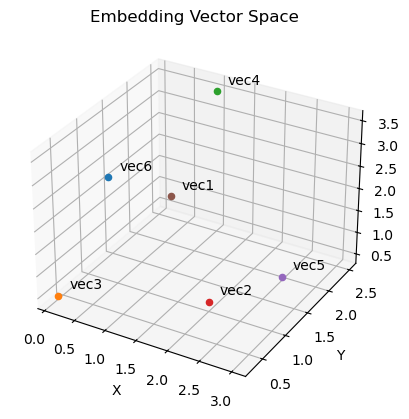

In [26]:
import matplotlib.pyplot as plt

# 3D 플롯을 생성합니다.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 각 벡터의 ID와 값을 사용하여 3D 공간에 점을 그립니다.
for i, id in enumerate(ids):
    if id == "qv":
        # 쿼리 벡터는 노란색 사각형으로 표시합니다.
        ax.scatter(values[i][0], values[i][1], values[i][2], label=id, color='y', s=50, marker='s')
        ax.text(values[i][0] + 0.1, values[i][1] + 0.1, values[i][2] + 0.1, id)
    else:
        # 나머지 벡터는 기본 색상으로 표시합니다.
        ax.scatter(values[i][0], values[i][1], values[i][2], label=id)
        ax.text(values[i][0] + 0.1, values[i][1] + 0.1, values[i][2] + 0.1, id)

# 축 레이블과 제목을 설정합니다.
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Embedding Vector Space')

# 플롯을 표시합니다.
plt.show()

# wiki 인덱스 생성하기

In [42]:
# Pinecone 인덱스를 생성합니다.
# 인덱스 이름은 "wiki"이고, 차원은 1536, 메트릭은 코사인 유사도를 사용합니다.
# 인덱스는 AWS의 us-east-1 리전에서 서버리스 사양으로 생성됩니다.
index_name = "wiki"

pc.create_index(
    name=index_name,
    dimension=1536,  # 모델 차원
    metric="cosine",  # 모델 메트릭
    spec=ServerlessSpec(
        cloud="aws",
        region="us-east-1"
    )
)

{
    "name": "wiki",
    "metric": "cosine",
    "host": "wiki-bbsrrnu.svc.aped-4627-b74a.pinecone.io",
    "spec": {
        "serverless": {
            "cloud": "aws",
            "region": "us-east-1"
        }
    },
    "status": {
        "ready": true,
        "state": "Ready"
    },
    "vector_type": "dense",
    "dimension": 1536,
    "deletion_protection": "disabled",
    "tags": null
}

In [43]:
# 'wiki' 인덱스를 가져옵니다.
index = pc.Index(index_name)

# 인덱스의 통계 정보를 설명합니다.
index.describe_index_stats()

{'dimension': 1536,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'total_vector_count': 0,
 'vector_type': 'dense'}

In [44]:
from datasets import load_dataset

# 예: 2023-11-01 덤프의 한국어(ko) 전체 학습 split, # 언어/스냅샷 선택
data = load_dataset("wikimedia/wikipedia", "20231101.ko", split="train[:100]")
print(data)
print(data[0])  # {'id', 'url', 'title', 'text', 'timestamp' ... 형식}

Dataset({
    features: ['id', 'url', 'title', 'text'],
    num_rows: 100
})
{'id': '5', 'url': 'https://ko.wikipedia.org/wiki/%EC%A7%80%EB%AF%B8%20%EC%B9%B4%ED%84%B0', 'title': '지미 카터', 'text': '제임스 얼 카터 주니어(, 1924년 10월 1일~)는 민주당 출신 미국의 제39대 대통령(1977년~1981년)이다.\n\n생애\n\n어린 시절 \n지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다.\n\n조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.\n\n정계 입문 \n1962년 조지아주 상원 의원 선거에서 낙선하였으나, 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주지사 선거에 낙선하지만, 1970년 조지아 주지사 선거에서 당선됐다. 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다. 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다.\n\n대통령 재임 \n\n1976년 미합중국 제39대 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워서, 많은 지지를 받았는데 제럴드 포드 대통령을 누르고 당선되었다.\n\n카터 대통령은 에너지 개발을 촉구했으나 공화당의 반대로 무산되었다.\n\n외교 정책 \n카터는 이집트와 이스라엘을 조정하여 캠프 데이비드에서 안와르 사다트 대통령과 메나헴 베긴 수상과 함께 중동 평화를 위한 캠프데이비드 협정을 체결했다. 이것은 공화당과 미국의 유대인 단체의 반발을 일으켰다. 그러나 1979년, 양국 간의 평화조약이 백악관에서 이루어졌다.\n\n소련과 제2차 전략 무기 제한 

In [45]:
from langchain_openai import OpenAIEmbeddings 

In [46]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# RecursiveCharacterTextSplitter를 초기화합니다.
# 이 클래스는 텍스트를 재귀적으로 문자 단위로 분할합니다.
splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,  # 분할할 텍스트의 크기
    #chunk_size=1000,  # 분할할 텍스트의 크기
    #chunk_size=2048,  # 분할할 텍스트의 크기
    #chunk_overlap=100,  # 분할된 텍스트의 중첩 크기
    chunk_overlap=20,  # 분할된 텍스트의 중첩 크기
    length_function=len,  # 텍스트 길이를 계산하는 함수
    separators=["\n\n", "\n", " ", ""]  # 분할할 텍스트의 구분자
)

splitter

In [47]:
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

In [48]:
from tqdm.auto import tqdm
from uuid import uuid4
import time

batch_size = 20  #한 번에 올린 upsert 요청 바디가 3MB, Pinecone 서버의 2MB 제한을 넘으면 오류 > 배치사이즈 작게 하기
texts = []
metas = []
count = 0

In [49]:
# 데이터셋의 각 샘플에 대해 반복합니다.
for i, sample in enumerate(tqdm(data)):

    full_text = sample["text"] # Wikipedia 문서 텍스트
    metadata = {
        'wiki_id': str(sample["id"]),  # Wikipedia 문서 ID
        'url': sample["url"],  # Wikipedia 문서 URL
        'title': sample["title"],  # Wikipedia 문서 제목
    }

		# 텍스트를 청크로 분할합니다.
    chunks = splitter.split_text(full_text)  # 텍스트를 청크로 분할합니다.
    #print(len(chunks))

    # 각 청크에 대해 반복합니다.
    for i, chunk in enumerate(chunks):
        record = {
            'chunk_id': i,  # 청크 ID
            'full_text': chunk[:300],  # 전체 텍스트
            **metadata,  # 메타데이터 언패킹
        }

        texts.append(chunk)  # 청크를 텍스트 목록에 추가합니다.
        metas.append(record)  # 메타데이터를 메타데이터 목록에 추가합니다.

        count += 1  # 처리된 청크 수를 증가시킵니다.

        # batch_size만큼의 청크를 처리할 때마다 청크를 Pinecone 인덱스에 추가합니다.
        if count % batch_size == 0:
            # Pinecone 인덱스에 청크를 추가합니다.
            ids = [str(uuid4()) for _ in range(len(texts))]
            embeddings = embedding_model.embed_documents(texts)
            index.upsert(
                vectors=zip(ids, embeddings, metas),
                namespace="wiki-ns1")
            # 청크 목록과 메타데이터 목록을 비웁니다.
            texts = []
            metas = []
            # 1초 대기합니다.
            time.sleep(1)

100%|██████████| 100/100 [08:41<00:00,  5.21s/it]


In [50]:
from langchain_pinecone import PineconeVectorStore

In [53]:
vectorstore = PineconeVectorStore.from_existing_index(
  index_name ='wiki',
  embedding=embedding_model,
  text_key='full_text',
  namespace='wiki-nsl'
)

In [54]:
# retriever 대신 similarity_search 직접 호출
results= vectorstore.similarity_search(
  query='대한민국의 수도는 어디인가요?',
  k=3,
  namespace='wiki-ns1'
)
print(f'결과 수 : {len(results)}')
for i, r in enumerate(results):
  print(f'\n [i+1]')
  print(f'page_content: {r.page_content[:100]}')
  print(f'metadata: {r.metadata}')

결과 수 : 3

 [i+1]
page_content: 각주

같이 보기 
 수도 이름순 수도 목록

나라 목록
수도 목록
metadata: {'chunk_id': 10.0, 'title': '나라 이름순 수도 목록', 'url': 'https://ko.wikipedia.org/wiki/%EB%82%98%EB%9D%BC%20%EC%9D%B4%EB%A6%84%EC%88%9C%20%EC%88%98%EB%8F%84%20%EB%AA%A9%EB%A1%9D', 'wiki_id': '79'}

 [i+1]
page_content: 2004년 10월 21일 헌법재판소는 "신행정수도특별법은 서울을 수도로 보아온 관습헌법에 어긋나는 일"이라며 수도 이전은 위헌이라는 판결을 내렸다. 수도는 서울이라는 것이 관습 헌
metadata: {'chunk_id': 88.0, 'title': '노무현', 'url': 'https://ko.wikipedia.org/wiki/%EB%85%B8%EB%AC%B4%ED%98%84', 'wiki_id': '85'}

 [i+1]
page_content: 정책이 신자유주의 우파에 가깝다는 비난을 받기도 했다. 진보 언론으로부터는 신자유주의자라고, 보수 언론에게는 반미주의자라며 양측 진영에서 모두 비판받은 대통령으로 평가받는다. 행정
metadata: {'chunk_id': 8.0, 'title': '노무현', 'url': 'https://ko.wikipedia.org/wiki/%EB%85%B8%EB%AC%B4%ED%98%84', 'wiki_id': '85'}


In [56]:
retriever = vectorstore.as_retriever(search_kwargs={"k":3,"namespace":"wiki-ns1"})

# 한국어 위키 기반 검색 테스트
queries = [
  "대한민국의 수도는 어디인가요?",
  "삼성전자는 어떤 회사인가요?",
  "한국의 전통 음식은 무엇인가요?"
]

In [57]:
for query in queries:
  print(f"[질문]{query}")
  results = retriever.invoke(query)
  for i, r in enumerate(results):
    print(f" {i+1}, [{r.metadata.get('title')}] {r.page_content[:80]}")
  print()

[질문]대한민국의 수도는 어디인가요?
 1, [나라 이름순 수도 목록] 각주

같이 보기 
 수도 이름순 수도 목록

나라 목록
수도 목록
 2, [노무현] 2004년 10월 21일 헌법재판소는 "신행정수도특별법은 서울을 수도로 보아온 관습헌법에 어긋나는 일"이라며 수도 이전은 위헌이라는 판결을 내렸
 3, [노무현] 정책이 신자유주의 우파에 가깝다는 비난을 받기도 했다. 진보 언론으로부터는 신자유주의자라고, 보수 언론에게는 반미주의자라며 양측 진영에서 모두 

[질문]삼성전자는 어떤 회사인가요?
 1, [구글] 구글()은 구글 검색을 중심으로 스마트폰 운영체제인 안드로이드와 유튜브 사업, 클라우드 사업을 하는 미국의 기업이다. 다양한 구글 서비스들(메일
 2, [구글] 2011년, 모토로라 인코퍼레이티드는 휴대전화사업과 본사의 사업부분이 불안정적으로 운영됨에 대한 걱정과 사업부 실적의 부진으로 인해 사업부가 모
 3, [노무현] 유행어 
 집권 당시 네티즌 사이에서 노무현과 전혀 무관한 인터넷 기사에 대해서도 '이게 다 노무현 때문이다'라는 댓글을 다는 것이 유행했다. 

[질문]한국의 전통 음식은 무엇인가요?
 1, [우크라이나] 음식 

우크라이나 전통음식은 닭고기, 돼지고기, 쇠고기, 생선, 버섯요리 등이 있다. 또한 우크라이나인들은 다량의 감자, 곡물, 신선하거나 절
 2, [음계] 계이름 
계이름은 음계를 기준으로 한 음의 이름이다. 장음계를 이루는 음의 계이름은 으뜸음부터 위로 올라가면서 각각 도, 레, 미, 파, 솔()
 3, [표준 모형] 우연한 대칭

